## CNN
Convolutional neural network working on data of the grammy's winner historic and trying to do predictions

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

### Setup: imports and dependencies

Import libraries used for data loading, preprocessing, modeling, and visualization.

In [ ]:
df_grammy_album = pd.read_csv('grammys-best album.csv')
df_money = pd.read_csv('money-makers-bb.csv')
df_rich = pd.read_csv('richest musicians by year.csv')

### Load datasets

Load CSV files with artist rankings, Grammy winners, revenue, and wealth information.

In [3]:
df_rank['Grammy_Win'] = df_rank['Artist'].isin(df_grammy_album['Artist']).astype

### Feature engineering — mark Grammy winners

Create a column that flags whether an artist in the rankings has a Grammy album win (useful as a binary feature).

In [4]:
features = ['Main Grammy awards', 'Main Grammy Nominations', 'Total Awards', 'Total Nominations', 'UK number 1\'s']
target = 'Rolling Stone Magazine Rank'

### Define features and target

Select columns to use as model inputs (features) and the target variable to predict.

In [5]:
X = df_rank[features].fillna(0)
y = df_rank[target]

### Prepare feature matrix `X` and target `y`

Fill missing values and extract `X` (features) and `y` (target). Ensure `X` has no NaNs before scaling.

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Scale features

Standardize features using `StandardScaler` so each feature has mean 0 and variance 1 for stable training.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

### Train / Test split

Split the scaled data into training and testing subsets to evaluate generalization.

In [9]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

C:\Users\ali\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Build model

A small feed-forward neural network for regression. Adjust units, layers, and regularization as needed.

In [10]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

### Compile model

Set optimizer, loss function, and evaluation metrics for training.

In [11]:
history = model.fit(X_train, y_train, epochs=50, batch_size=8, validation_split=0.2)




Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 3431.0630 - mae: 51.4686 - val_loss: 3784.4397 - val_mae: 52.3488
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3405.6846 - mae: 51.2397 - val_loss: 3755.3206 - val_mae: 52.0431
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3383.9292 - mae: 51.0192 - val_loss: 3725.5476 - val_mae: 51.7252
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3356.9216 - mae: 50.7343 - val_loss: 3692.1665 - val_mae: 51.3717
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3332.0669 - mae: 50.5028 - val_loss: 3653.5967 - val_mae: 50.9643
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3299.9487 - mae: 50.1835 - val_loss: 3607.2319 - val_mae: 50.5444
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3253.8716 - mae: 49.7255 - val_loss: 3551.7507 - val_mae: 50.0579
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3205.5034 - mae: 49.1678 - val_loss: 3485.0837 - val_mae: 49.5171
Epoch 9/50
8/8 ━━━

### Train model

Fit the model to the training data. Monitor validation loss and metrics to detect overfitting.

In [12]:
test_loss, test_mae = model.evaluate(X_test, y_test)
print(f"Test MAE: {test_mae}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 1005.3073 - mae: 26.6825
Test MAE: 26.6824951171875


### Evaluate model

Evaluate model performance on the held-out test set and print test MAE.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load all datasets
df_rank = pd.read_csv('best artists_RS.csv')
df_grammy_album = pd.read_csv('grammys-best album.csv')
df_grammy_record = pd.read_csv('grammys-best record.csv')
df_money = pd.read_csv('money-makers-bb.csv')
df_rich = pd.read_csv('richest musicians by year.csv')

# Let's view the structure of each
print("=== Dataset Shapes ===")
print(f"Rankings: {df_rank.shape}")
print(f"Grammy Album Winners: {df_grammy_album.shape}")
print(f"Grammy Record Winners: {df_grammy_record.shape}")
print(f"Money Makers: {df_money.shape}")
print(f"Richest by Year: {df_rich.shape}")

=== Dataset Shapes ===
Rankings: (100, 8)
Grammy Album Winners: (63, 7)
Grammy Record Winners: (64, 4)
Money Makers: (120, 7)
Richest by Year: (34, 5)


### Visualizations and exploratory analysis

Create visual summaries to compare Grammy winners and overall artist demographics.

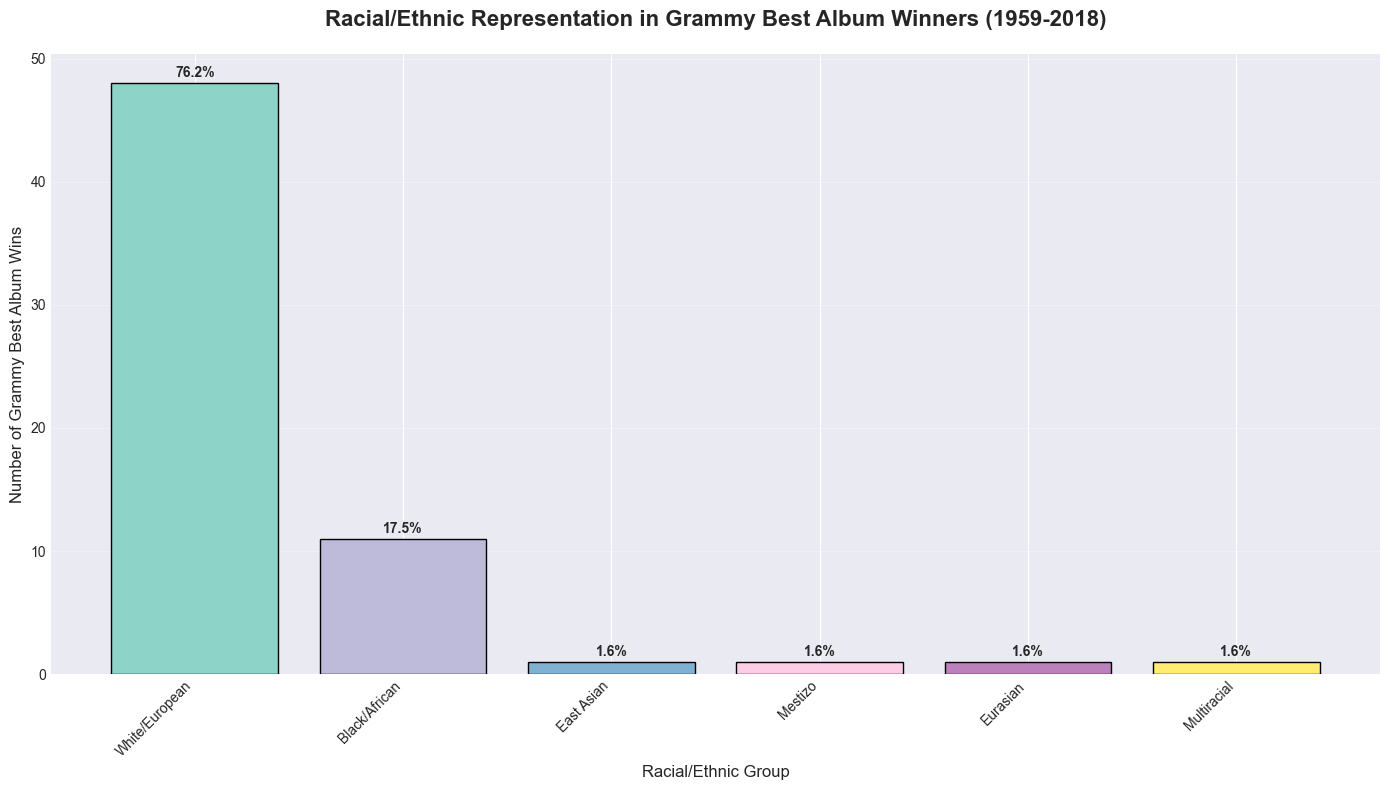

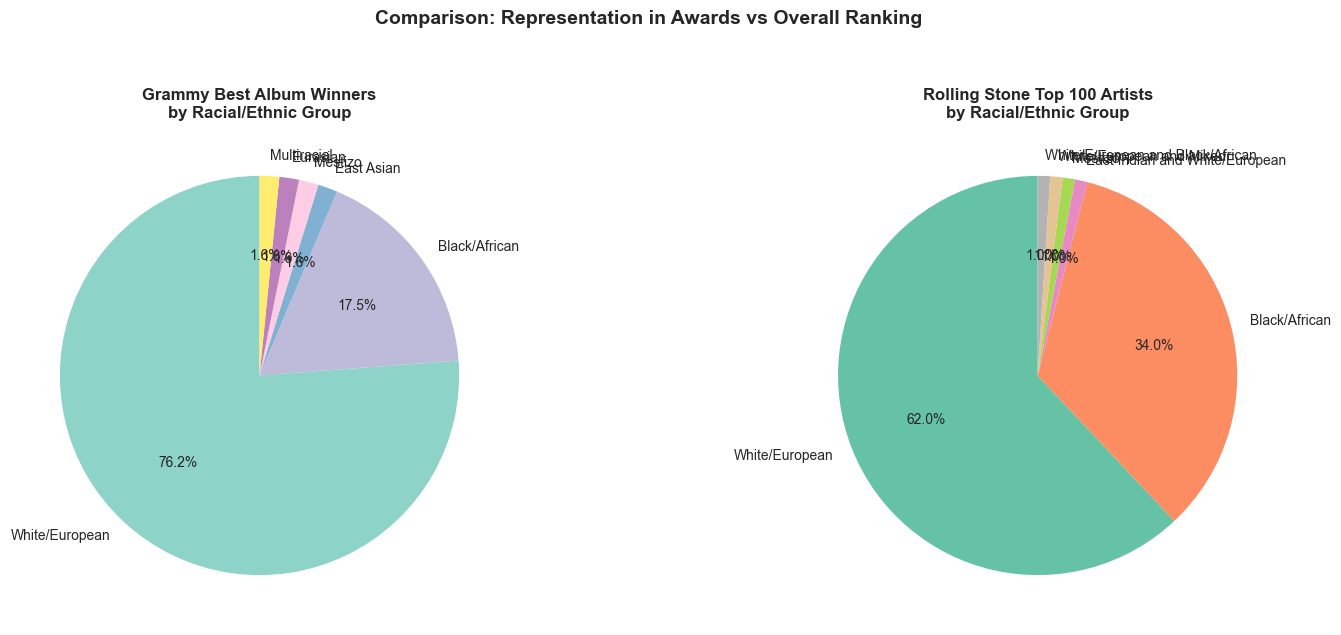


=== Representation Analysis ===
Percentage of Grammy Best Album Winners by Group:
  White/European: 48 wins (76.2%)
  Black/African: 11 wins (17.5%)
  East Asian: 1 wins (1.6%)
  Mestizo: 1 wins (1.6%)
  Eurasian: 1 wins (1.6%)
  Multiracial: 1 wins (1.6%)


In [19]:
# Let's analyze Grammy winners by racial/ethnic group
# We have two Grammy datasets: Album and Record winners

# Clean and combine Grammy winners
df_grammy_winners = pd.concat([
    df_grammy_album[['Artist', 'Racial/Ethnic group']],
    df_grammy_record[['Artist', 'Genre']].rename(columns={'Genre': 'Racial/Ethnic group'})
], ignore_index=True)

# For this visualization, let's focus on the Grammy Album winners which have racial data
# Count by racial/ethnic group
grammy_counts = df_grammy_album['Racial/Ethnic group'].value_counts()

# Create a more readable color palette
colors = cm.Set3(np.linspace(0, 1, len(grammy_counts)))

# Plot bar chart
plt.figure(figsize=(14, 8))
bars = plt.bar(range(len(grammy_counts)), grammy_counts.values, color=colors, edgecolor='black')

# Add percentage labels
total = grammy_counts.sum()
for i, (bar, count) in enumerate(zip(bars, grammy_counts.values)):
    percentage = (count / total) * 100
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{percentage:.1f}%', ha='center', fontweight='bold')

plt.title('Racial/Ethnic Representation in Grammy Best Album Winners (1959-2018)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Racial/Ethnic Group', fontsize=12)
plt.ylabel('Number of Grammy Best Album Wins', fontsize=12)
plt.xticks(range(len(grammy_counts)), grammy_counts.index, rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Add a second visualization: Compare with overall artist population
plt.figure(figsize=(16, 6))

# Subplot 1: Grammy Winners
plt.subplot(1, 2, 1)
grammy_pct = (grammy_counts / grammy_counts.sum() * 100)
plt.pie(grammy_pct.values, labels=grammy_pct.index, autopct='%1.1f%%', 
        startangle=90, colors=colors, textprops={'fontsize': 10})
plt.title('Grammy Best Album Winners\nby Racial/Ethnic Group', fontweight='bold')

# Subplot 2: All Artists in Rolling Stone Top 100
rank_counts = df_rank['Racial/Ethnic group'].value_counts()
rank_pct = (rank_counts / rank_counts.sum() * 100)
colors2 = cm.Set2(np.linspace(0, 1, len(rank_counts)))

plt.subplot(1, 2, 2)
plt.pie(rank_pct.values, labels=rank_pct.index, autopct='%1.1f%%', 
        startangle=90, colors=colors2, textprops={'fontsize': 10})
plt.title('Rolling Stone Top 100 Artists\nby Racial/Ethnic Group', fontweight='bold')

plt.suptitle('Comparison: Representation in Awards vs Overall Ranking', 
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# Calculate disparity index
print("\n=== Representation Analysis ===")
print("Percentage of Grammy Best Album Winners by Group:")
for group, count in grammy_counts.items():
    pct = (count / grammy_counts.sum()) * 100
    print(f"  {group}: {count} wins ({pct:.1f}%)")

### Analysis: Grammy winners representation

Process Grammy datasets and visualize racial/ethnic group distributions to identify representation disparities.